<a href="https://colab.research.google.com/github/Roaa27/LSTM_CNN/blob/main/LSTM_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install opencv-python -q
!apt-get install unrar -q

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     TimeDistributed, LSTM, Dense,
                                     Dropout, BatchNormalization,
                                     Bidirectional, Input)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Reading package lists...
Building dependency tree...
Reading state information...
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [35]:
IMG_SIZE   = 64
N_FRAMES   = 20
N_CLASSES  = 15
BATCH_SIZE = 8
EPOCHS     = 60
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [36]:
import os
print(os.path.exists("UCF-101"))

True


!wget -q --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
!unrar x UCF101.rar

In [37]:
!ls /content/UCF-101

ApplyEyeMakeup	   Drumming	       MilitaryParade	   Shotput
ApplyLipstick	   Fencing	       Mixing		   SkateBoarding
Archery		   FieldHockeyPenalty  MoppingFloor	   Skiing
BabyCrawling	   FloorGymnastics     Nunchucks	   Skijet
BalanceBeam	   FrisbeeCatch        ParallelBars	   SkyDiving
BandMarching	   FrontCrawl	       PizzaTossing	   SoccerJuggling
BaseballPitch	   GolfSwing	       PlayingCello	   SoccerPenalty
Basketball	   Haircut	       PlayingDaf	   StillRings
BasketballDunk	   Hammering	       PlayingDhol	   SumoWrestling
BenchPress	   HammerThrow	       PlayingFlute	   Surfing
Biking		   HandstandPushups    PlayingGuitar	   Swing
Billiards	   HandstandWalking    PlayingPiano	   TableTennisShot
BlowDryHair	   HeadMassage	       PlayingSitar	   TaiChi
BlowingCandles	   HighJump	       PlayingTabla	   TennisSwing
BodyWeightSquats   HorseRace	       PlayingViolin	   ThrowDiscus
Bowling		   HorseRiding	       PoleVault	   TrampolineJumping
BoxingPunchingBag  HulaHoop	       PommelH

In [54]:
CLASSES = [
    "WalkingWithDog", "JumpingJack", "PushUps", "Basketball",
    "SoccerJuggling", "VolleyballSpiking", "TennisSwing", "Punch",
    "PlayingGuitar", "PlayingPiano", "GolfSwing", "HorseRiding",
    "SkateBoarding", "Surfing", "Bowling"
]

LABELS_MAP = {
    0: "Walking With Dog",    1: "Jumping Jack",      2: "Push Ups",
    3: "Basketball",          4: "Soccer Juggling",   5: "Volleyball Spiking",
    6: "Tennis Swing",        7: "Punch",             8: "Playing Guitar",
    9: "Playing Piano",      10: "Golf Swing",        11: "Horse Riding",
   12: "Skate Boarding",     13: "Surfing",           14: "Bowling"
}
DESCRIPTIONS = {
    0: "Person walking with a dog",
    1: "Person jumping with arms and legs spread",
    2: "Person doing push-ups",
    3: "Person playing basketball",
    4: "Person juggling a soccer ball",
    5: "Person spiking a volleyball",
    6: "Person swinging a tennis racket",
    7: "Person punching",
    8: "Person playing guitar",
    9: "Person playing piano",
    10: "Person playing golf",
    11: "Person riding a horse",
    12: "Person skateboarding",
    13: "Person surfing on waves",
    14: "Person bowling"
}

In [39]:
def extract_frames(video_path, n_frames=N_FRAMES):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    indices = np.linspace(0, total-1, n_frames).astype(int)
    frames = []

    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = frame.astype("float32") / 255.0
            frames.append(frame)

    cap.release()
    return frames


In [40]:
DATA_PATH = "/content/UCF-101"
data, labels = [], []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_PATH, cls)
    videos = os.listdir(folder)
    random.shuffle(videos)
    videos = videos[:100]

    for vid in videos:
        frames = extract_frames(os.path.join(folder, vid))
        if len(frames) == N_FRAMES:
            data.append(frames)
            labels.append(label)

    print(f"✅ {cls}: {len([v for v in videos])} videos")

X = np.array(data,   dtype="float32")
y = to_categorical(np.array(labels), N_CLASSES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED,
    stratify=np.argmax(y, axis=1)
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

✅ WalkingWithDog: 100 videos
✅ JumpingJack: 100 videos
✅ PushUps: 100 videos
✅ Basketball: 100 videos
✅ SoccerJuggling: 100 videos
✅ VolleyballSpiking: 100 videos
✅ TennisSwing: 100 videos
✅ Punch: 100 videos
✅ PlayingGuitar: 100 videos
✅ PlayingPiano: 100 videos
✅ GolfSwing: 100 videos
✅ HorseRiding: 100 videos
✅ SkateBoarding: 100 videos
✅ Surfing: 100 videos
✅ Bowling: 100 videos

Train: (1132, 20, 64, 64, 3) | Test: (283, 20, 64, 64, 3)


In [41]:
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256, (3,3), activation='relu', padding='same'),  # 🔥 جديد
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Dropout(0.4),
    Flatten()
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model = Sequential([TimeDistributed(cnn, input_shape=(N_FRAMES, IMG_SIZE, IMG_SIZE, 3)),

    Bidirectional(LSTM(256, return_sequences=False)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(N_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 20, 4096)       │       390,336 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 512)            │     8,914,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,339,343 (35.63 MB)

 Trainable params: 9,338,255 (35.62 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [43]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [44]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 39s 131ms/step - accuracy: 0.1776 - loss: 2.8893 - val_accuracy: 0.2756 - val_loss: 2.2021 - learning_rate: 0.0010
Epoch 2/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.2129 - loss: 2.5859 - val_accuracy: 0.2686 - val_loss: 2.1083 - learning_rate: 0.0010
Epoch 3/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.2306 - loss: 2.4962 - val_accuracy: 0.3216 - val_loss: 2.0379 - learning_rate: 0.0010
Epoch 4/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.2712 - loss: 2.3216 - val_accuracy: 0.3322 - val_loss: 2.0509 - learning_rate: 0.0010
Epoch 5/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.2845 - loss: 2.2548 - val_accuracy: 0.4064 - val_loss: 1.8202 - learning_rate: 0.0010
Epoch 6/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.3012 - loss: 2.1525 - val_accuracy: 0.2686 - val_loss: 2.4781 - learning_rate: 0.0010
Epoch 7/60
142/142 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.3

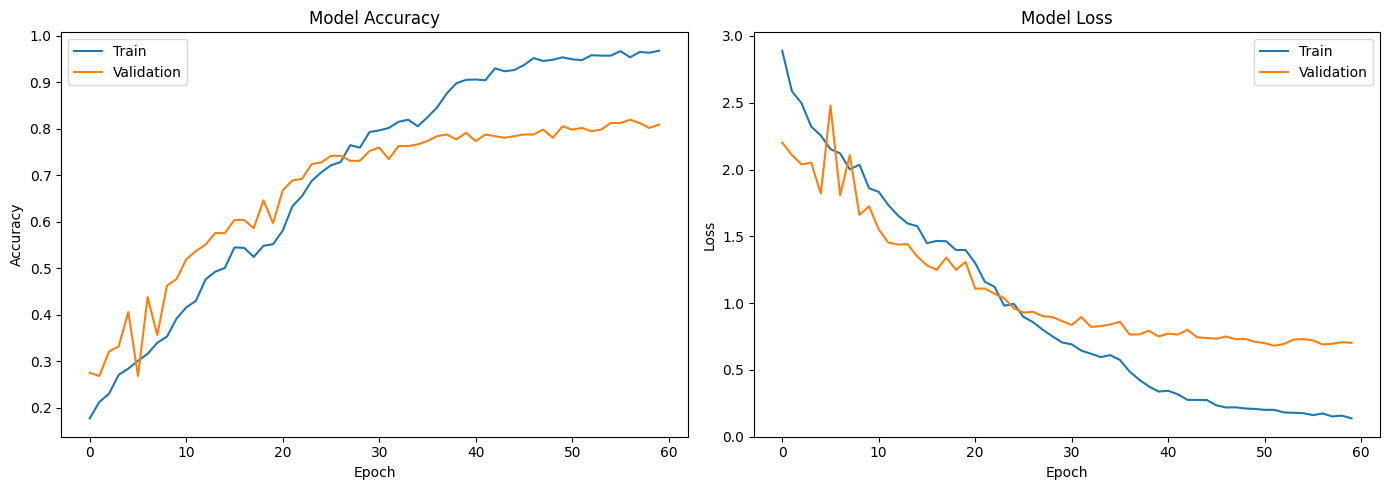

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Test Accuracy: {acc*100:.2f}%")
print(f"📉 Test Loss:     {loss:.4f}")


🎯 Test Accuracy: 81.98%
📉 Test Loss:     0.6909


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


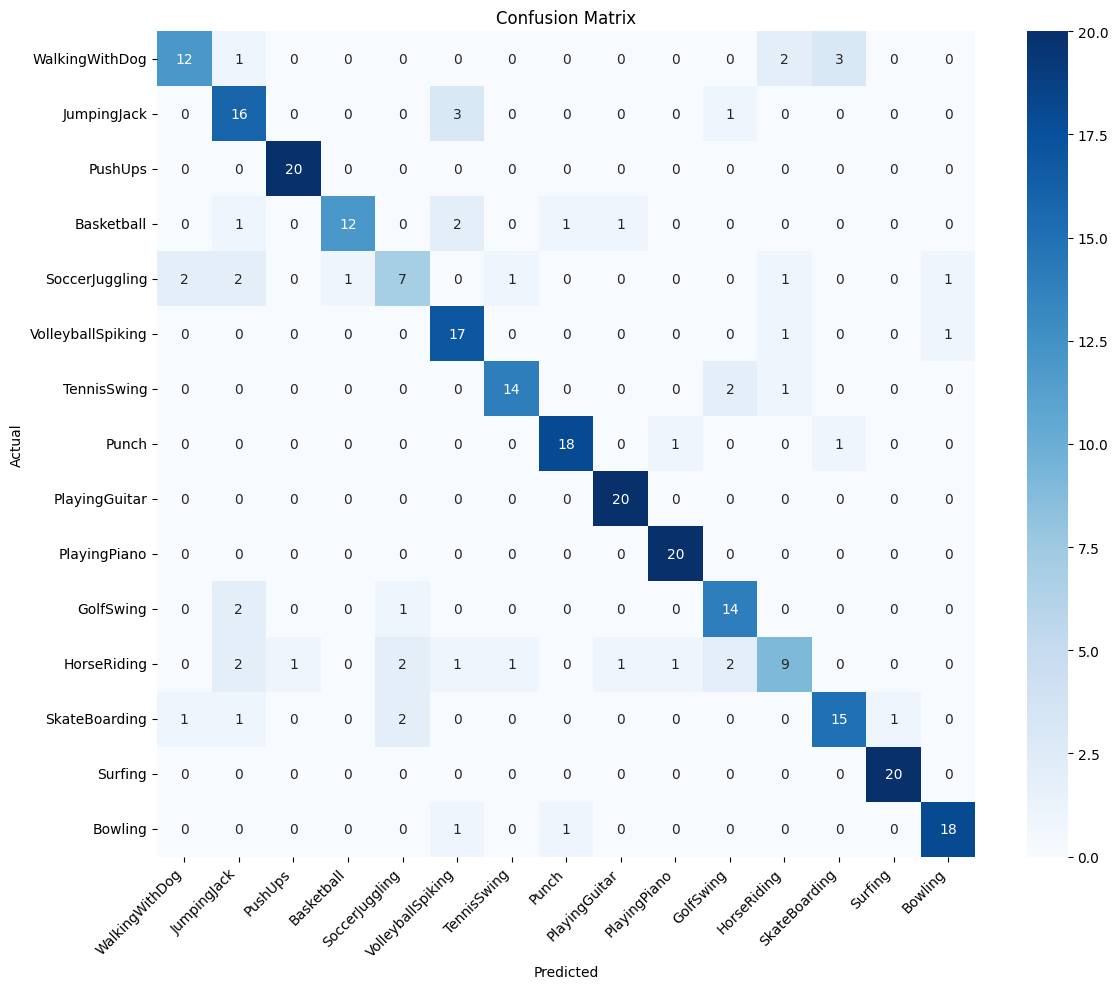

In [50]:
y_pred        = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true         = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [48]:
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASSES))


📊 Classification Report:
                   precision    recall  f1-score   support

   WalkingWithDog       0.80      0.67      0.73        18
      JumpingJack       0.64      0.80      0.71        20
          PushUps       0.95      1.00      0.98        20
       Basketball       0.92      0.71      0.80        17
   SoccerJuggling       0.58      0.47      0.52        15
VolleyballSpiking       0.71      0.89      0.79        19
      TennisSwing       0.88      0.82      0.85        17
            Punch       0.90      0.90      0.90        20
    PlayingGuitar       0.91      1.00      0.95        20
     PlayingPiano       0.91      1.00      0.95        20
        GolfSwing       0.74      0.82      0.78        17
      HorseRiding       0.64      0.45      0.53        20
    SkateBoarding       0.79      0.75      0.77        20
          Surfing       0.95      1.00      0.98        20
          Bowling       0.90      0.90      0.90        20

         accuracy           

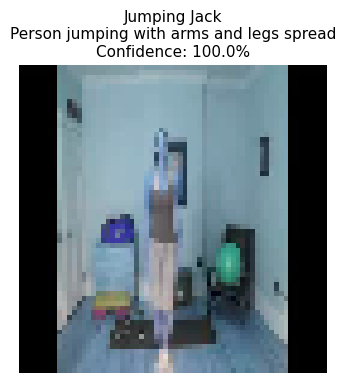

✅ Prediction : Jumping Jack
🧠 Description: Person jumping with arms and legs spread
📊 Confidence : 99.95%


In [55]:
def test_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) < N_FRAMES:
        print("❌ Video too short")
        return

    input_data = np.expand_dims(np.array(frames[:N_FRAMES]), axis=0)
    pred        = model.predict(input_data, verbose=0)
    pred_class  = np.argmax(pred)
    confidence  = np.max(pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(frames[0])
    plt.title(
        f"{LABELS_MAP[pred_class]}\n"
        f"{DESCRIPTIONS[pred_class]}\n"
        f"Confidence: {confidence*100:.1f}%",
        fontsize=11
    )
    plt.axis('off')
    plt.show()

    print(f"✅ Prediction : {LABELS_MAP[pred_class]}")
    print(f"🧠 Description: {DESCRIPTIONS[pred_class]}")
    print(f"📊 Confidence : {confidence*100:.2f}%")

test_video("/content/UCF-101/JumpingJack/v_JumpingJack_g01_c01.avi")

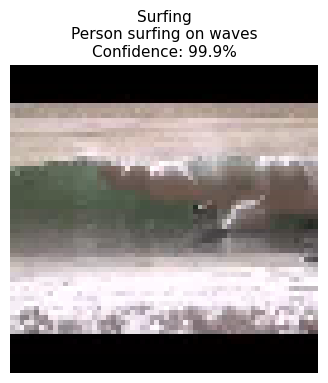

✅ Prediction : Surfing
🧠 Description: Person surfing on waves
📊 Confidence : 99.93%


In [56]:
test_video("/content/UCF-101/Surfing/v_Surfing_g01_c01.avi")

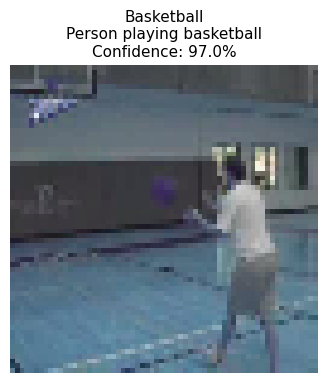

✅ Prediction : Basketball
🧠 Description: Person playing basketball
📊 Confidence : 96.99%


In [57]:
test_video("/content/UCF-101/Basketball/v_Basketball_g02_c03.avi")